<a href="https://colab.research.google.com/github/S-Yatheesh/DSA-B10-Final_Exam/blob/main/DSA_B10_EXAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


TASK 1:Data Undestanding & Exploration

In [2]:
df=pd.read_csv('G1.csv')
df.head()

,Response_ID,Timestamp,Age,Gender,Occupation_Status,Country_Region,Monthly_Income_Range,Shop_Most_Where,Online_Shopping_Frequency,Preferred_Platform,...,Return_Frequency,Avg_Monthly_Spend_NonEssentials,Preferred_Payment_Method,Uses_BNPL_Installments,Online_Shopping_Satisfaction_Score,Trust_In_Online_Reviews_Score,Regret_After_Purchase_Frequency,Reason_Prefer_Online,Reason_Prefer_InStore,Best_Shopping_Mode
0,1,01/08/2026 12:30:25,20,Male,NaN,Philippines,"Under $1,000",Equal mix,Often,Physical stores,...,Never,Under $50,Digital wallet,"Yes, occasionally",6.0,7.0,2.0,More variety,No delivery wait,Online
1,2,21/06/2026 13:52:02,24,Male,Employed part-time,Brazil,"Under $1,000",In-store only,Often,Local e-commerce,...,Often,Under $50,Digital wallet,"No, never",5.0,8.0,3.0,NaN,Try product before buying,Offline
2,3,15/08/2026 04:24:18,22,Female,Student,India,"Under $1,000",Equal mix,Always,Local e-commerce,...,Sometimes,$150-300,Credit Card,"No, never",7.0,6.0,2.0,Better prices,Trust,Online
3,4,23/06/2026 21:24:21,20,Male,Student,NaN,"Under $1,000",In-store only,Occasionally,Brand websites,...,Never,Under $50,Debit Card,"No, never",8.0,7.0,3.0,Better prices,Try product before buying,Equal / both
4,5,20/08/2026 16:24:47,41,Male,Employed full-time,United States,"$1,000-3,000",Equal mix,Occasionally,NaN,...,Sometimes,$50-150,Debit Card,"No, never",6.0,8.0,2.0,Convenience,Trust,Equal / both


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Response_ID                         500 non-null    int64  
 1   Timestamp                           500 non-null    object 
 2   Age                                 478 non-null    object 
 3   Gender                              484 non-null    object 
 4   Occupation_Status                   479 non-null    object 
 5   Country_Region                      480 non-null    object 
 6   Monthly_Income_Range                479 non-null    object 
 7   Shop_Most_Where                     484 non-null    object 
 8   Online_Shopping_Frequency           481 non-null    object 
 9   Preferred_Platform                  486 non-null    object 
 10  Primary_Device                      492 non-null    object 
 11  Top_Spending_Category               476 non-n

In [4]:
print(df.describe().T)

                                    count        mean         std  min  \
Response_ID                         500.0  250.500000  144.481833  1.0   
Review_Influence_Score              485.0    3.053608    1.128707  1.0   
Social_Ads_Influence_Score          479.0    3.079332    1.228144  1.0   
Price_Comparison_Frequency          474.0    4.139241    0.943219  1.0   
Discount_Importance_Score           477.0    3.821803    0.989284  1.0   
Likely_To_Buy_After_Ad_Score        475.0    3.016842    1.109857  1.0   
Impulse_Purchase_Frequency          484.0    2.590909    1.162741  1.0   
Online_Shopping_Satisfaction_Score  457.0    7.126915    1.592636  2.0   
Trust_In_Online_Reviews_Score       450.0    6.160000    1.918425  1.0   
Regret_After_Purchase_Frequency     448.0    2.187500    0.902705  1.0   

                                       25%    50%     75%    max  
Response_ID                         125.75  250.5  375.25  500.0  
Review_Influence_Score                2.00    3.0  

In [5]:
print(df.dtypes)

Response_ID                             int64
Timestamp                              object
Age                                    object
Gender                                 object
Occupation_Status                      object
Country_Region                         object
Monthly_Income_Range                   object
Shop_Most_Where                        object
Online_Shopping_Frequency              object
Preferred_Platform                     object
Primary_Device                         object
Top_Spending_Category                  object
Review_Influence_Score                float64
Social_Ads_Influence_Score            float64
Price_Comparison_Frequency            float64
Discount_Importance_Score             float64
Follows_Brands_On_Social               object
Likely_To_Buy_After_Ad_Score          float64
Makes_Shopping_List                    object
Impulse_Purchase_Frequency            float64
Return_Frequency                       object
Avg_Monthly_Spend_NonEssentials   

In [6]:
df.shape

(500, 30)

In [7]:
df.nunique()

,0
Response_ID,500
Timestamp,500
Age,43
Gender,3
Occupation_Status,5
Country_Region,18
Monthly_Income_Range,4
Shop_Most_Where,3
Online_Shopping_Frequency,4
Preferred_Platform,4


In [8]:
for col in ['Age', 'Monthly_Income_Range', 'Online_Shopping_Frequency', 'Avg_Monthly_Spend_NonEssentials']:
    print(f"{col}: {df[col].dropna().unique()}")

Age: ['20' '24' '22' '41' '32' '21' '18' '37' '36' '25' '17' '34' '39' '31'
 '16' '26' '19' '27' '29' '30' '42' '35' '47' '33' '28' '23' '50' '48'
 '43' '40' 'rahul' 'test' '38' '46' 'xyz' '49' 'N/A123' '45' 'asdf' '44'
 '...' 'Gunay B' 'Priya K']
Monthly_Income_Range: ['Under $1,000' '$1,000-3,000' '$6,000+' '$3,000-6,000']
Online_Shopping_Frequency: ['Often' 'Always' 'Occasionally' 'Rarely']
Avg_Monthly_Spend_NonEssentials: ['Under $50' '$150-300' '$50-150' '$500+' '$300-500']


In [9]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].fillna(df['Age'].median())

income_order = ['Under $1,000', '$1,000-3,000', '$3,000-6,000', '$6,000+']
frequency_order = ['Rarely', 'Occasionally', 'Often', 'Always']
spend_order = ['Under $50', '$50-150', '$150-300', '$300-500', '$500+']


In [10]:
df.columns

Index(['Response_ID', 'Timestamp', 'Age', 'Gender', 'Occupation_Status',
       'Country_Region', 'Monthly_Income_Range', 'Shop_Most_Where',
       'Online_Shopping_Frequency', 'Preferred_Platform', 'Primary_Device',
       'Top_Spending_Category', 'Review_Influence_Score',
       'Social_Ads_Influence_Score', 'Price_Comparison_Frequency',
       'Discount_Importance_Score', 'Follows_Brands_On_Social',
       'Likely_To_Buy_After_Ad_Score', 'Makes_Shopping_List',
       'Impulse_Purchase_Frequency', 'Return_Frequency',
       'Avg_Monthly_Spend_NonEssentials', 'Preferred_Payment_Method',
       'Uses_BNPL_Installments', 'Online_Shopping_Satisfaction_Score',
       'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency',
       'Reason_Prefer_Online', 'Reason_Prefer_InStore', 'Best_Shopping_Mode'],
      dtype='object')

In [11]:
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [12]:
print(numeric_cols)

Index(['Response_ID', 'Age', 'Review_Influence_Score',
       'Social_Ads_Influence_Score', 'Price_Comparison_Frequency',
       'Discount_Importance_Score', 'Likely_To_Buy_After_Ad_Score',
       'Impulse_Purchase_Frequency', 'Online_Shopping_Satisfaction_Score',
       'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency'],
      dtype='object')


In [13]:
print(categorical_cols)

Index(['Timestamp', 'Gender', 'Occupation_Status', 'Country_Region',
       'Monthly_Income_Range', 'Shop_Most_Where', 'Online_Shopping_Frequency',
       'Preferred_Platform', 'Primary_Device', 'Top_Spending_Category',
       'Follows_Brands_On_Social', 'Makes_Shopping_List', 'Return_Frequency',
       'Avg_Monthly_Spend_NonEssentials', 'Preferred_Payment_Method',
       'Uses_BNPL_Installments', 'Reason_Prefer_Online',
       'Reason_Prefer_InStore', 'Best_Shopping_Mode'],
      dtype='object')


In [14]:
print(df.isnull().sum())
print('\n')
df.duplicated().sum()

Response_ID                            0
Timestamp                              0
Age                                    0
Gender                                16
Occupation_Status                     21
Country_Region                        20
Monthly_Income_Range                  21
Shop_Most_Where                       16
Online_Shopping_Frequency             19
Preferred_Platform                    14
Primary_Device                         8
Top_Spending_Category                 24
Review_Influence_Score                15
Social_Ads_Influence_Score            21
Price_Comparison_Frequency            26
Discount_Importance_Score             23
Follows_Brands_On_Social              11
Likely_To_Buy_After_Ad_Score          25
Makes_Shopping_List                   24
Impulse_Purchase_Frequency            16
Return_Frequency                      17
Avg_Monthly_Spend_NonEssentials       20
Preferred_Payment_Method              15
Uses_BNPL_Installments                12
Online_Shopping_

np.int64(0)

<function matplotlib.pyplot.show(close=None, block=None)>

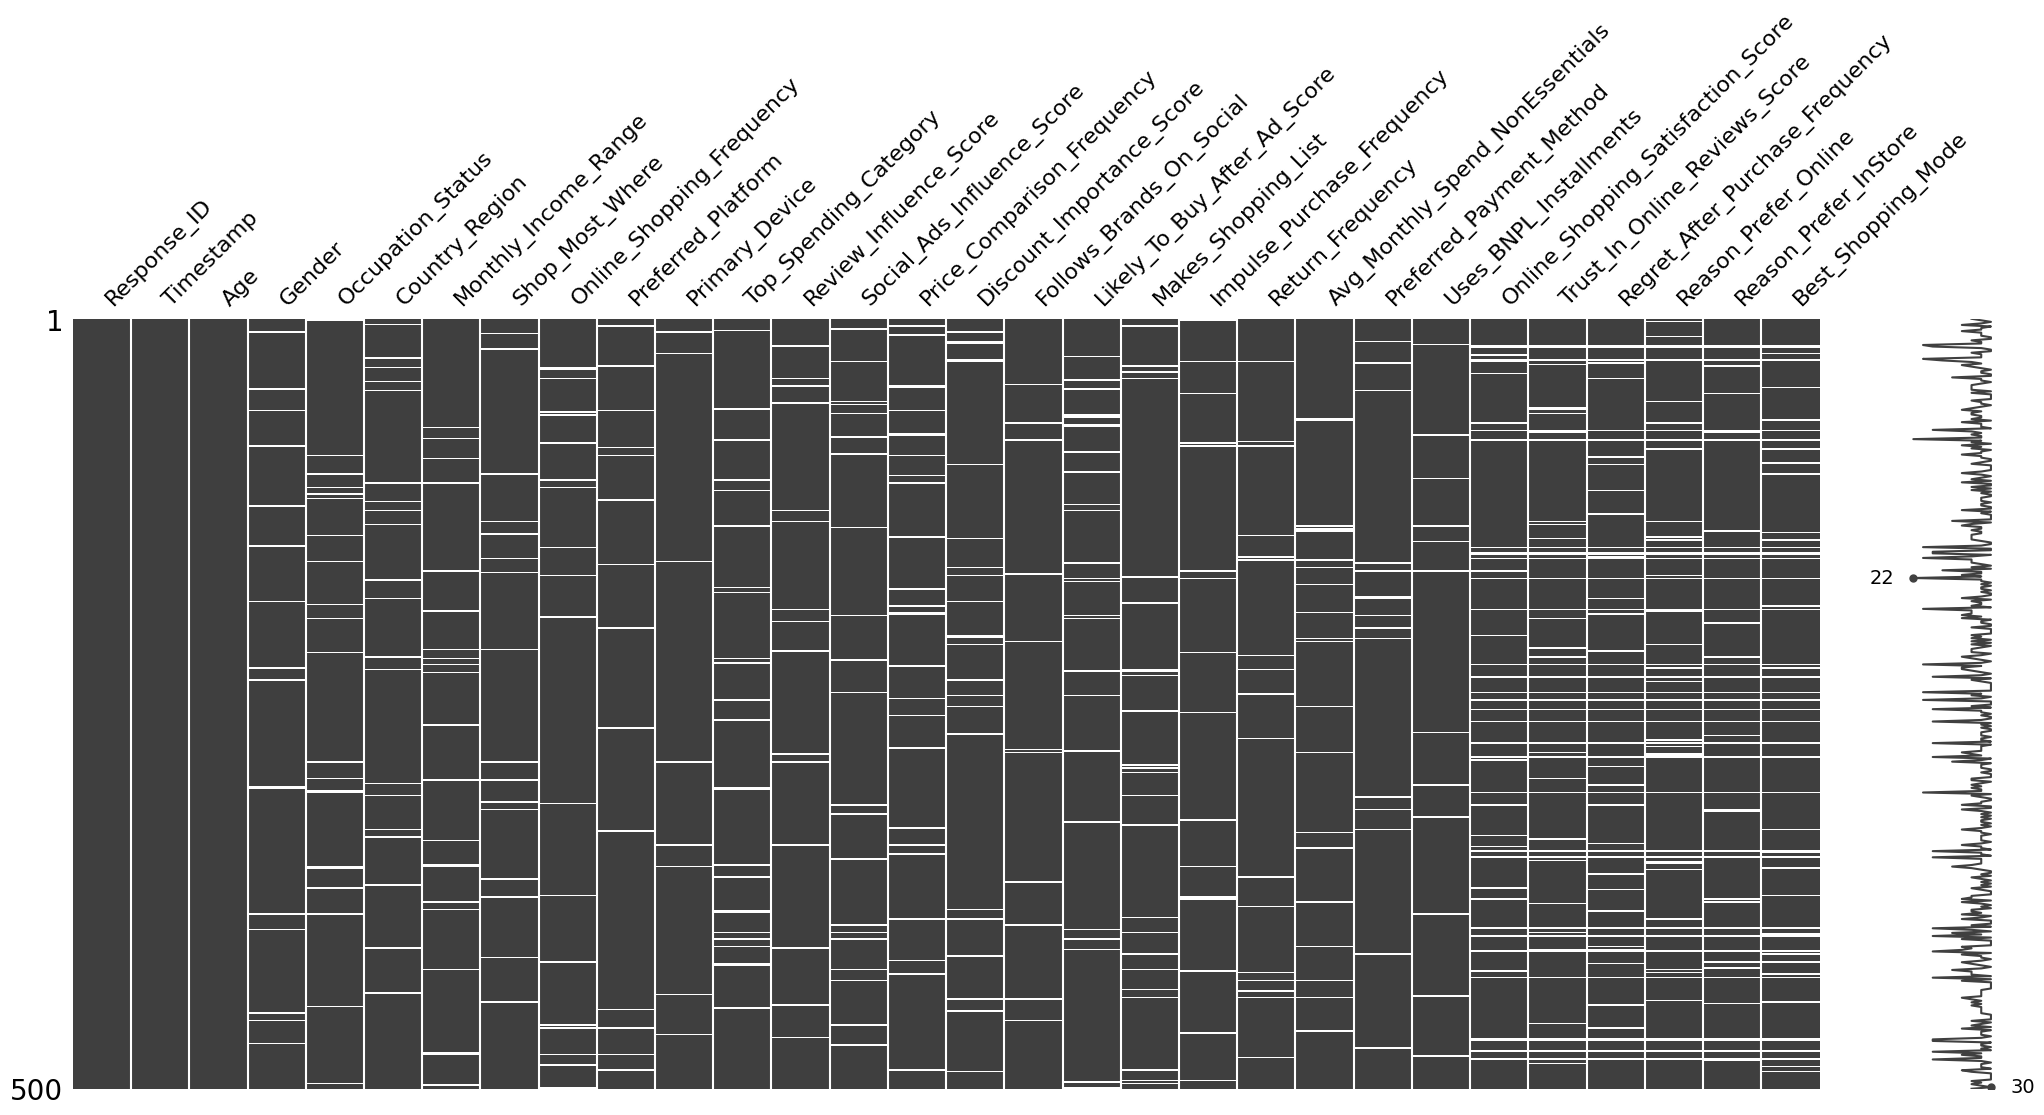

In [15]:
df.isnull().mean()
import missingno as msno
msno.matrix(df)
plt.show

Summary Statistics:
count    475.000000
mean       3.016842
std        1.109857
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: Likely_To_Buy_After_Ad_Score, dtype: float64

Value counts:
Likely_To_Buy_After_Ad_Score
1.0     43
2.0    115
3.0    152
4.0    121
5.0     44
Name: count, dtype: int64


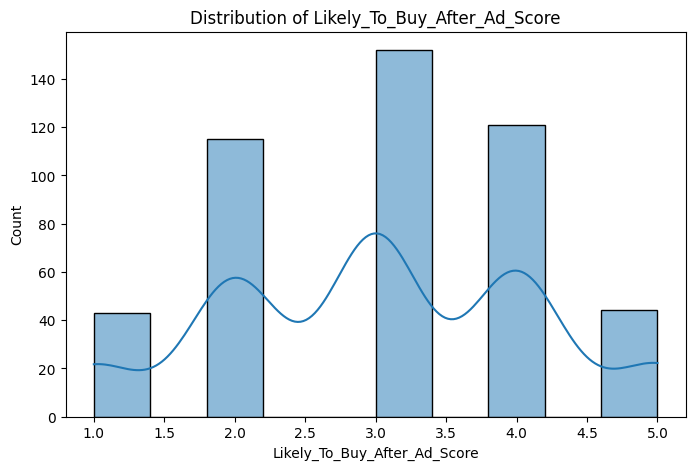

In [16]:
target = "Likely_To_Buy_After_Ad_Score"

df[target] = pd.to_numeric(df[target], errors="coerce")

summary = df[target].describe()
print("Summary Statistics:")
print(summary)

print("\nValue counts:")
print(df[target].value_counts().sort_index())

# Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df[target].dropna(), kde=True, bins=10)
plt.title(f"Distribution of {target}")
plt.xlabel(target)
plt.ylabel("Count")
plt.show()

#TASK 2: Data Preprocessing

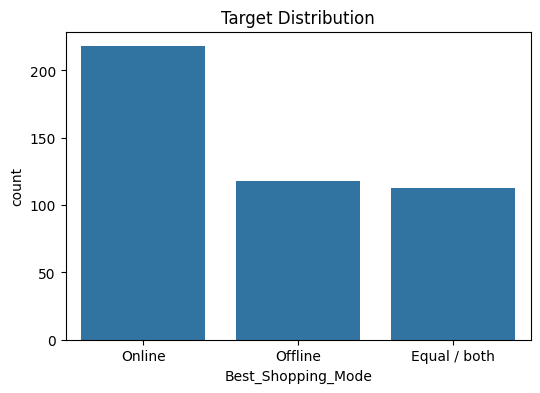

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Best_Shopping_Mode")
plt.title("Target Distribution")
plt.show()

In [18]:
columns_to_drop = [
    'Response_ID',
    'Timestamp',
    'Reason_Prefer_Online',
    'Reason_Prefer_InStore',
    'Shop_Most_Where',
    'Likely_To_Buy_After_Ad_Score',
    'Trust_In_Online_Reviews_Score'
]
df_cleaned = df.drop(columns=columns_to_drop)

In [19]:
for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object':
        df_cleaned[col] = df_cleaned[col].fillna('Unknown')
    else:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

<function matplotlib.pyplot.show(close=None, block=None)>

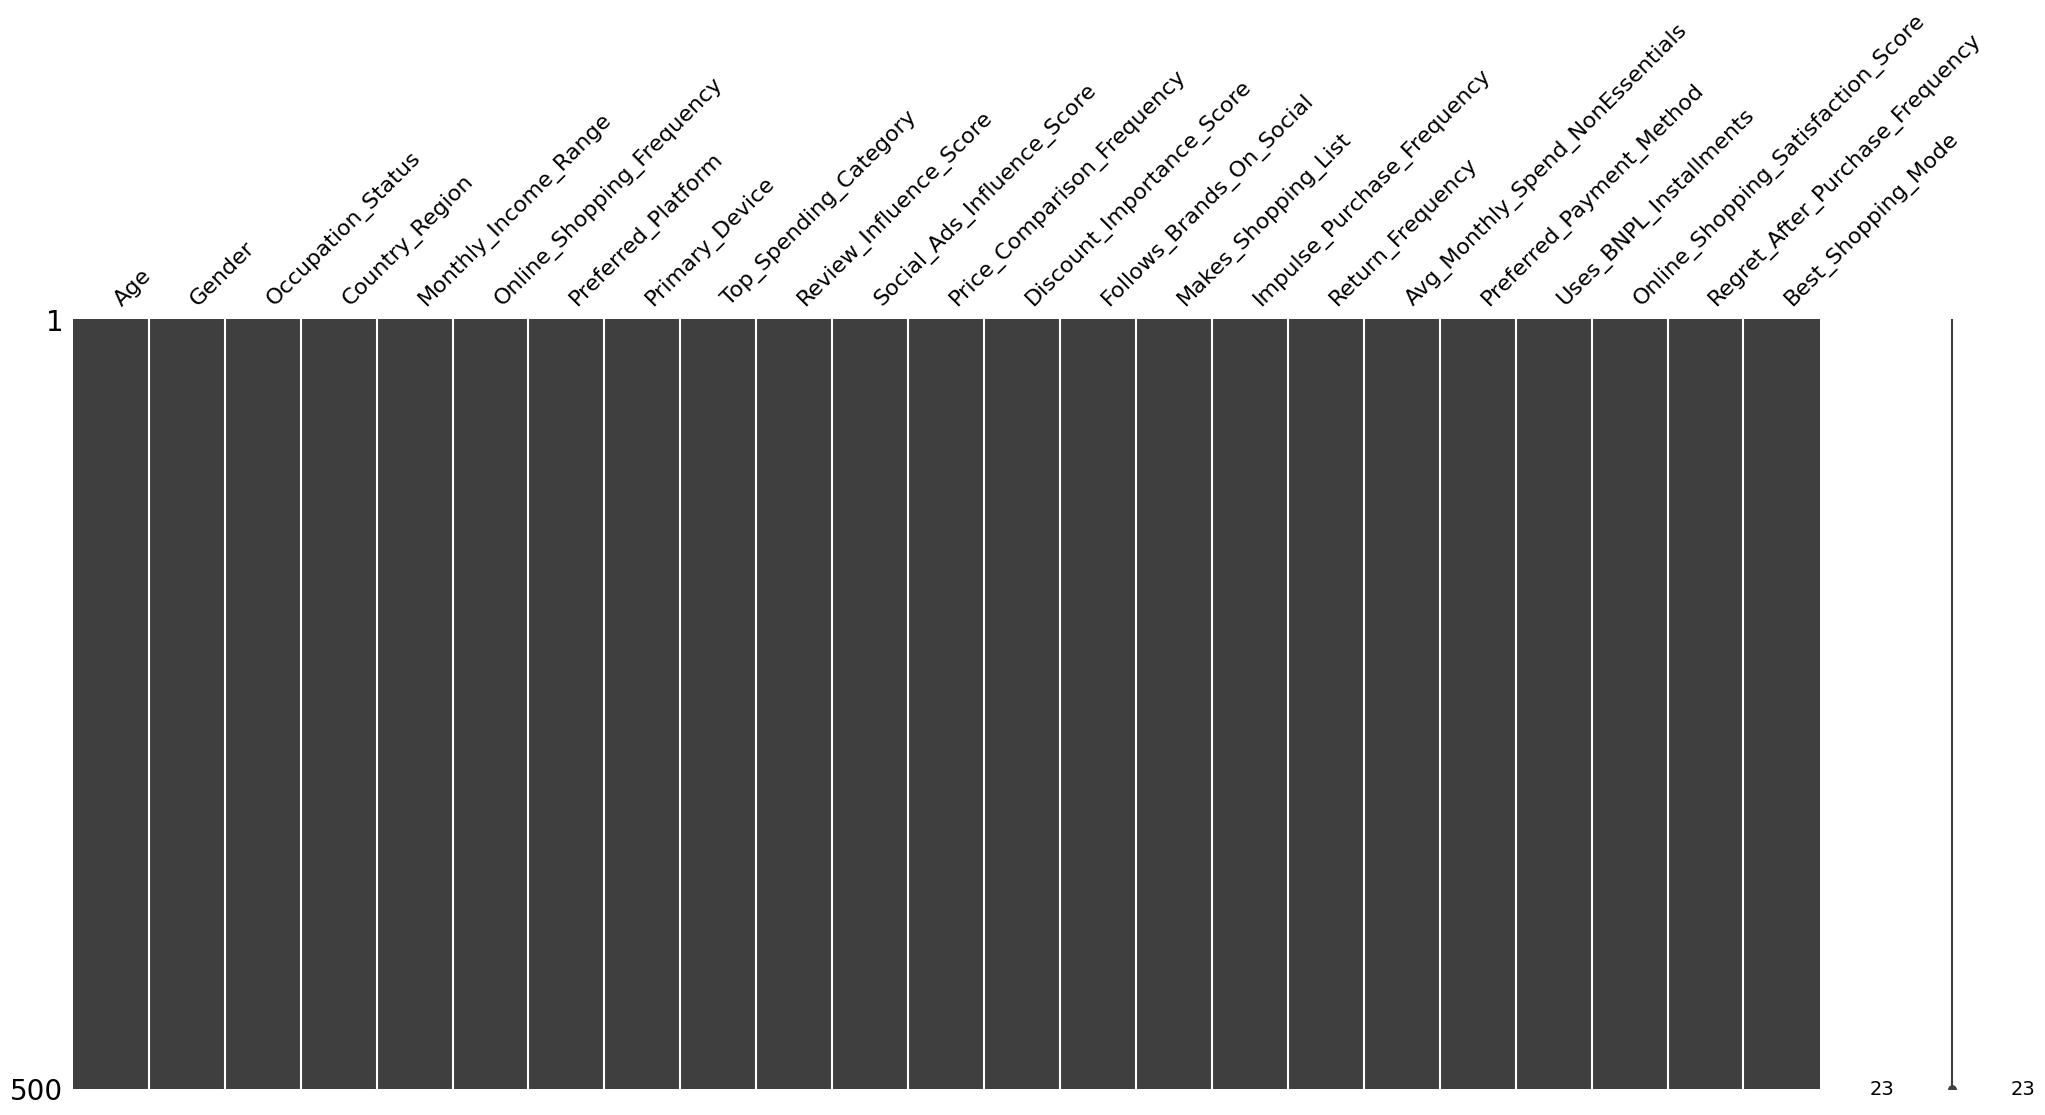

In [20]:
import missingno as msno
msno.matrix(df_cleaned)
plt.show

In [21]:
X = df_cleaned.drop(columns=['Best_Shopping_Mode'])
y = df_cleaned['Best_Shopping_Mode']

In [22]:
ordinal_cols = ['Monthly_Income_Range', 'Online_Shopping_Frequency', 'Return_Frequency', 'Avg_Monthly_Spend_NonEssentials']

nominal_cols = ['Age', 'Gender', 'Occupation_Status', 'Country_Region', 'Preferred_Platform', 'Primary_Device', 'Top_Spending_Category', 'Follows_Brands_On_Social',
'Makes_Shopping_List', 'Preferred_Payment_Method', 'Uses_BNPL_Installments']

numeric_cols = ['Review_Influence_Score', 'Social_Ads_Influence_Score', 'Price_Comparison_Frequency','Discount_Importance_Score', 'Impulse_Purchase_Frequency', 'Online_Shopping_Satisfaction_Score',
'Regret_After_Purchase_Frequency']

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [24]:
encoded_nominal_names = preprocessor.named_transformers_['nom'].get_feature_names_out(nominal_cols).tolist()
all_feature_names = ordinal_cols + encoded_nominal_names + numeric_cols

1.The preprocessing desicions such as removing the unwanted columns are one of the main

2.Improper handling of missing values affect predictions such as by prediciting wrong data when model preparation. As the model will give very Diffrent Values to the user rater than oriinal one .

#TASK 3:Exploratory Data Analysis

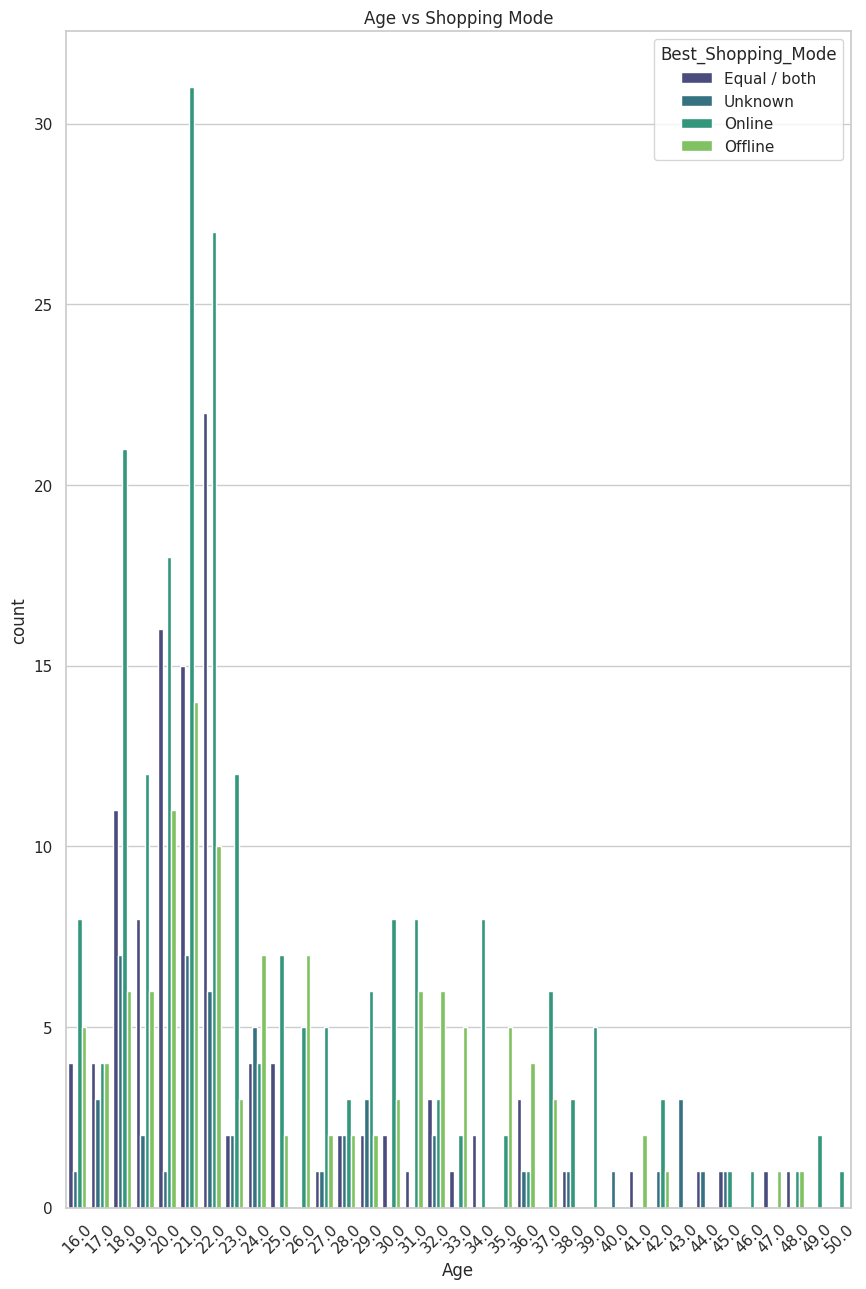

In [25]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(25, 25))

plt.subplot(2, 3, 1)
sns.countplot(data=df_cleaned, x='Age', hue='Best_Shopping_Mode', palette='viridis')
plt.title('Age vs Shopping Mode')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

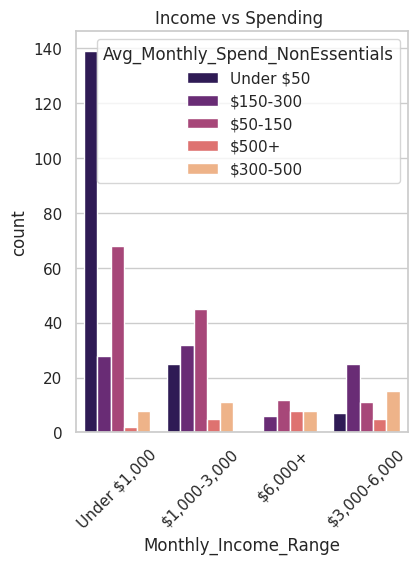

In [26]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12,10))

plt.subplot(2, 3, 2)

sns.countplot(data=df, x='Monthly_Income_Range', hue='Avg_Monthly_Spend_NonEssentials', palette='magma')
plt.title('Income vs Spending ')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


/tmp/ipykernel_50297/3209663745.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Online_Shopping_Frequency', palette='Set2')


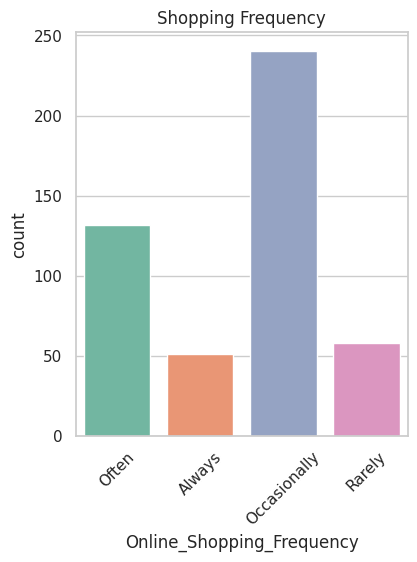

In [27]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12,10))

plt.subplot(2, 3, 3)
sns.countplot(data=df, x='Online_Shopping_Frequency', palette='Set2')
plt.title('Shopping Frequency')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


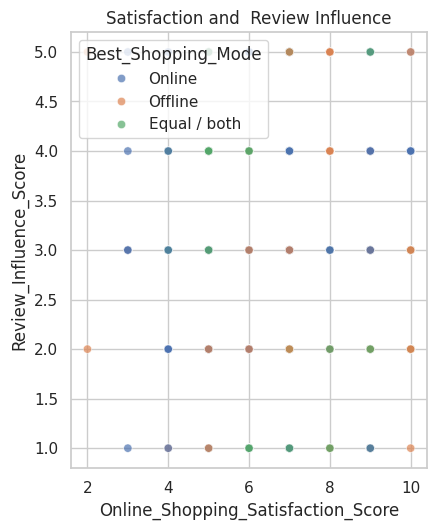

In [28]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12,10))

plt.subplot(2, 3, 4)
sns.scatterplot(data=df, x='Online_Shopping_Satisfaction_Score', y='Review_Influence_Score', hue='Best_Shopping_Mode', alpha=0.7)
plt.title('Satisfaction and  Review Influence')

plt.tight_layout()
plt.show()

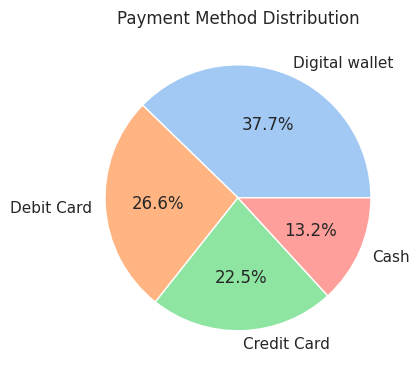

In [29]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))

plt.subplot(2, 3, 5)
payment_counts = df['Preferred_Payment_Method'].value_counts()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Payment Method Distribution')

plt.tight_layout()
plt.show()

1.The major factor to influence online shopping is Review score recieving via online also the Age is a main factor , more of the online users are coming in the age division of 18-23 and then the graph visualizes as very down and th

2.Yes . in the higher income customers , the group which spend in between 150-300 dollars is higher in that division.

3.Yes , the customer satsifaction is related to review , and here the plot shows offline shopping have more review score than online shopping . It will affect both medium of shopping.

#TASK 4:Machine Learning Model

In [30]:

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_transformed, y_train)

y_pred = rf_model.predict(X_test_transformed)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.4
              precision    recall  f1-score   support

Equal / both       0.22      0.09      0.12        23
     Offline       0.33      0.12      0.18        24
      Online       0.43      0.81      0.56        43
     Unknown       0.00      0.00      0.00        10

    accuracy                           0.40       100
   macro avg       0.25      0.26      0.22       100
weighted avg       0.31      0.40      0.31       100



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', random_state=42, class_weight='balanced')
}

performance_metrics = {}

for model_name, model_obj in models.items():

    model_obj.fit(X_train_transformed, y_train)

    y_pred = model_obj.predict(X_test_transformed)


    performance_metrics[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='macro', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='macro', zero_division=0)
    }

In [32]:
df_comparison = pd.DataFrame(performance_metrics).T
print("\n    MODEL PERFORMANCE COMPARISON MATRIX    ")
print(df_comparison.round(4))

best_model_name = df_comparison['F1-Score'].idxmax()
best_model = models[best_model_name]
print(f"\n Best Selected Model based on F1-Score: {best_model_name}")

y_best_pred = best_model.predict(X_test_transformed)
cm = confusion_matrix(y_test, y_best_pred, labels=best_model.classes_)


    MODEL PERFORMANCE COMPARISON MATRIX    
                        Accuracy  Precision  Recall  F1-Score
Logistic Regression         0.25     0.2077  0.1995    0.1956
Random Forest               0.37     0.1813  0.2294    0.1828
Gradient Boosting           0.36     0.2984  0.2621    0.2565
Support Vector Machine      0.20     0.2065  0.2116    0.1870

 Best Selected Model based on F1-Score: Gradient Boosting


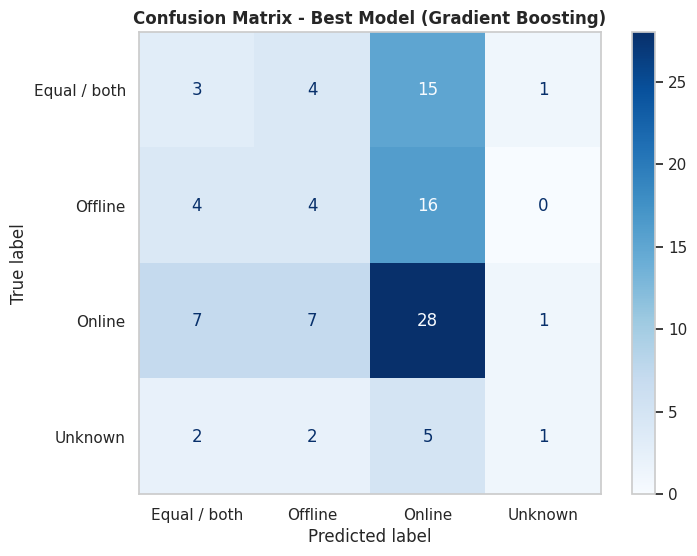

In [33]:
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'Confusion Matrix - Best Model ({best_model_name})', fontsize=12, fontweight='bold')
plt.grid(False)
plt.show()

In [34]:
print("\n--- TOP RANKED MARKETING PREDICTORS ---")

if best_model_name in ["Random Forest", "Gradient Boosting"]:
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Marketing_Feature': all_feature_names,
        'Importance_Weight': importances
    }).sort_values(by='Importance_Weight', ascending=False)

    print(feature_importance_df.head(10).to_string(index=False))

elif best_model_name == "Logistic Regression":
    importances = np.mean(np.abs(best_model.coef_), axis=0)
    feature_importance_df = pd.DataFrame({
        'Marketing_Feature': all_feature_names,
        'Absolute_Coefficient_Weight': importances
    }).sort_values(by='Absolute_Coefficient_Weight', ascending=False)

    print(feature_importance_df.head(10).to_string(index=False))

else:
    from sklearn.inspection import permutation_importance
    result = permutation_importance(best_model, X_test_transformed, y_test, n_repeats=5, random_state=42)
    feature_importance_df = pd.DataFrame({
        'Marketing_Feature': all_feature_names,
        'Permutation_Importance_Weight': result.importances_mean
    }).sort_values(by='Permutation_Importance_Weight', ascending=False)

    print(feature_importance_df.head(10).to_string(index=False))


--- TOP RANKED MARKETING PREDICTORS ---
                 Marketing_Feature  Importance_Weight
Online_Shopping_Satisfaction_Score           0.067951
            Review_Influence_Score           0.034825
         Occupation_Status_Student           0.031261
   Regret_After_Purchase_Frequency           0.029258
         Discount_Importance_Score           0.027027
         Makes_Shopping_List_Never           0.025012
              Monthly_Income_Range           0.024843
   Avg_Monthly_Spend_NonEssentials           0.024203
   Top_Spending_Category_Groceries           0.021897
        Price_Comparison_Frequency           0.021179


1.Gradient Boosting performed very well because it mainly have tree ensembles and also the non linear relationship with columns helping the best predictions among the models.

2.Online_Shopping_Satisfaction_Score, Top_Spending_Category are the most contributed features to prediction.

3.In related to Confusion matrix, The model having difficult to predict the 'Equal and Both' class because the model trying to consider that as either online or either offline

#TASK 5 : Flask Web Application


In [35]:
import pickle
from google.colab import files

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

with open('shopping_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

files.download('preprocessor.pkl')
files.download('shopping_model.pkl')

print("Success! Both pkl files have been serialized and downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Success! Both pkl files have been serialized and downloaded.
